In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [2]:
def animation(x,t,w,l,T,k):
    fig, ax = plt.subplots(figsize=(8,4))
    linha, = ax.plot(x, w[:,0], lw=2)
    plt.grid()
    ax.set_xlim(0, l)
    ax.set_ylim(np.min(w), np.max(w))

    ax.set_xlabel("x")
    ax.set_ylabel("w(x,t)")

    def update(frame):

        linha.set_ydata(w[:,frame])

        ax.set_title(f"t = {t[frame]:.3f}")

        return linha,

    ani = FuncAnimation(
        fig,
        update,
        frames= round(T/k) + 1,
        interval=20,
        blit=True
    )

    plt.show()

    ani.save(
        "wave.gif",
        writer="pillow",
        fps=30
    )

In [3]:
def plot_3d(x, t, w):
    x_valores = x
    t_valores = t

    X, T = np.meshgrid(x_valores, t_valores)

    if w.shape != X.shape:
        W = w.T
    else:
        W = w

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    superficie = ax.plot_surface(X, T, W, cmap='viridis', edgecolor='none', alpha=0.9)

    ax.set_title('Visualização 3D da aproximação w(x,t)', fontsize=14)
    ax.set_xlabel('Espaço (x)', fontsize=12)
    ax.set_ylabel('Tempo (t)', fontsize=12)
    ax.set_zlabel('Solução (w)', fontsize=12)

    fig.colorbar(superficie, ax=ax, shrink=0.5, aspect=10, label='Valores de w')

    plt.show()
    fig.colorbar(superficie, ax=ax, shrink=0.5, aspect=10, label='Valores de w')

    plt.show()

In [4]:
def plot_heatmap(x, t, w):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    c = ax.contourf(x, t, w.T, levels=50, cmap='RdBu_r')
    plt.colorbar(c, ax=ax, label='u(x, t)')
    
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    ax.set_title('Heatmap — Wave Equation')
    plt.tight_layout()
    plt.show()

## Finite Difference Method — 1D Wave Equation

### Problem

$$\frac{\partial^2 u}{\partial t^2} = \alpha^2 \frac{\partial^2 u}{\partial x^2}, \quad x \in [0, l],\ t \in [0, T]$$

with boundary and initial conditions:

$$u(0, t) = u(l, t) = 0$$

$$u(x, 0) = f(x), \qquad \frac{\partial u}{\partial t}(x, 0) = g(x)$$



### Discretization

Grid nodes with steps $h = \Delta x$ and $k = \Delta t$:

$$x_i = ih,\ i = 0,\ldots,m \qquad t_j = jk,\ j = 0,\ldots,n$$

Replacing both derivatives with second-order central differences:

$$\frac{w_{i,j+1} - 2w_{i,j} + w_{i,j-1}}{k^2} = \alpha^2\, \frac{w_{i+1,j} - 2w_{i,j} + w_{i-1,j}}{h^2}$$

where $\lambda = \dfrac{\alpha k}{h}$ is the **Courant number**.

### Explicit Scheme

**First step** ($j=0 \to j=1$), using Taylor expansion with $g(x)$:

$$w_{i,1} = (1-\lambda^2)\,f(x_i) + \frac{\lambda^2}{2}\bigl[f(x_{i+1}) + f(x_{i-1})\bigr] + k\,g(x_i)$$

**General step** ($j \geq 1$):

$$w_{i,j+1} = 2(1-\lambda^2)\,w_{i,j} + \lambda^2\bigl(w_{i+1,j} + w_{i-1,j}\bigr) - w_{i,j-1}$$

In [5]:
def mdf_onda(l,T,h,k,f,g,alpha):
    #Número de passos:
    m = round(((l/h)))
    n = round(((T/k)))

    #Discretização
    w = np.zeros(shape = ((m + 1),(n + 1)))
    x = np.linspace(0,l,m + 1)
    t = np.linspace(0,T,n + 1)
    lamb = alpha*k/h

    #Valores iniciais:
    w[:, 0] = f(x[:])
    w[0, :],w[m, :] = 0 , 0

    for i in range(1,m):
        w[i, 1] = (1 - lamb**2)*f(x[i]) + lamb**2/2 * (f(x[i + 1]) + f(x[i - 1])) + k*g(x[i])

    for j in range(1,n):

        for i in range(1, m):
            w[i, j + 1] = 2*(1 - lamb**2)*w[i,j] + lamb**2 * (w[i + 1,j] + w[i - 1,j]) - w[i, j - 1]

    return x,t,w


### Example:

$$
\frac{\partial^2 u}{\partial t^2}(x,t) - 4\frac{\partial^2 u}{\partial x^2}(x,t) = 0, \quad 0 < x < 1, \quad t > 0
$$

$$
u(0,t) = u(1,t) = 0, \quad t > 0
$$
$$

u(x,0) = \sin(\pi x), \quad \frac{\partial u}{\partial t}(x,0) = 0, \quad 0 \leq x \leq 1

$$

In [6]:
def f(x):
    return np.sin(np.pi*x)

def g(x):
    return 0

x,t,w = mdf_onda(1,2,0.1,0.05,f,g,2)

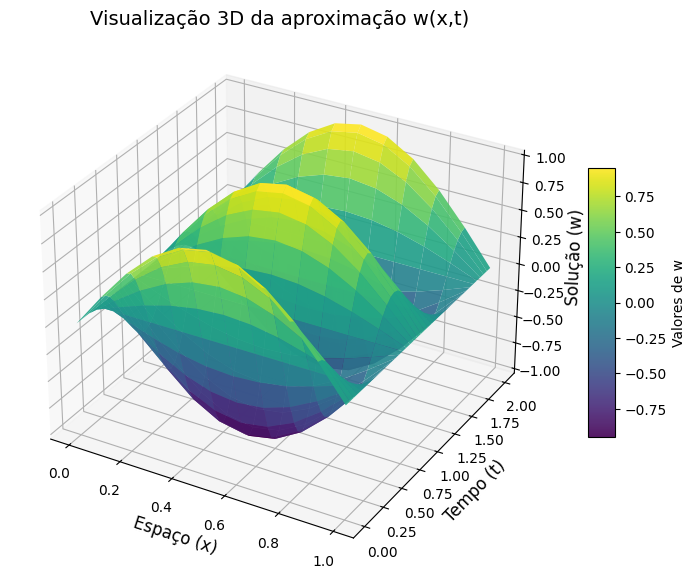

In [7]:
plot_3d(x,t,w)

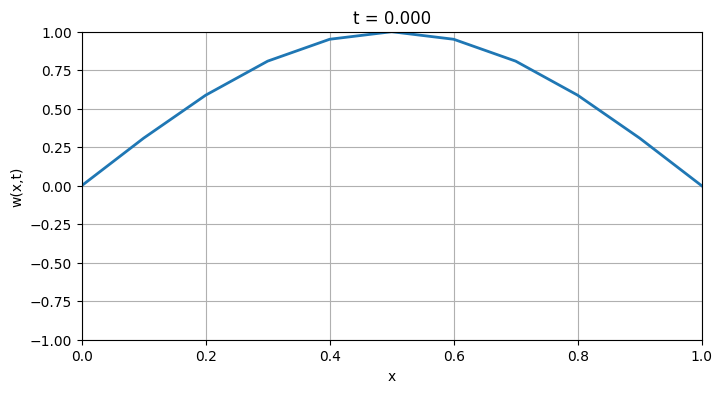

In [8]:
animation(x,t,w,1,2,0.05)

### Example

$$\frac{\partial^2 u}{\partial t^2}(x, t) - \frac{1}{16\pi^2} \frac{\partial^2 u}{\partial x^2}(x, t) = 0, \quad 0 < x < 0.5, \quad t > 0,$$

$$\begin{aligned}
u(0, t) &= u(0.5, t) = 0, \quad t > 0 \\[1em]
u(x, 0) &= 0, \quad \frac{\partial u}{\partial t}(x, 0) = \sin(4\pi x), \quad 0 \le x \le 0.5.
\end{aligned}$$

In [9]:
x,t,w = mdf_onda(0.5,0.5,0.01,0.01,lambda x : 0, lambda x : np.sin(4*np.pi*x),1/(4*np.pi))

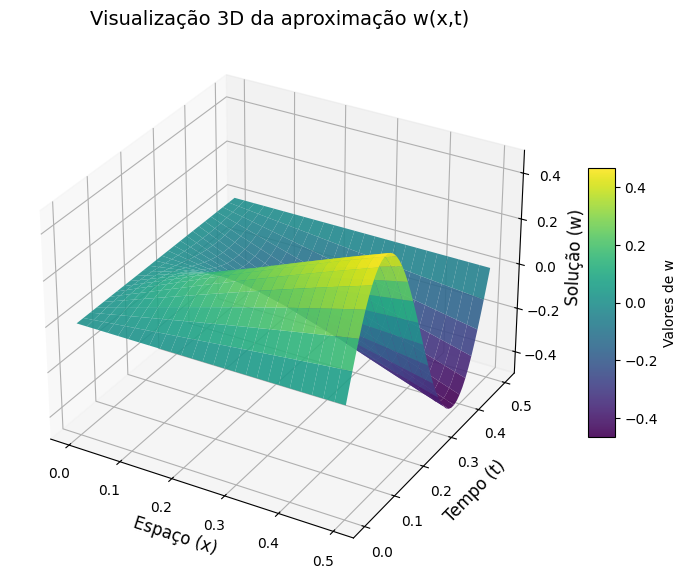

In [10]:
plot_3d(x,t,w)